In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
from pathlib import Path

print(Path.cwd())

c:\Users\Sreoshi\anomaly-detection\notebooks


In [87]:
from pathlib import Path

data_path = Path("../data/raw/abohar_weather.csv")

print(data_path.resolve())
print(data_path.exists())

df = pd.read_csv(data_path, skiprows=2)

df.head()

C:\Users\Sreoshi\anomaly-detection\data\raw\abohar_weather.csv
True


,time,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01T00:00,3.0,96,1021.5
1,2020-01-01T01:00,2.5,97,1021.0
2,2020-01-01T02:00,1.9,98,1021.0
3,2020-01-01T03:00,1.7,98,1021.1
4,2020-01-01T04:00,1.5,99,1021.1


In [88]:
df["time"] = pd.to_datetime(df["time"])

df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01 00:00:00,3.0,96,1021.5
1,2020-01-01 01:00:00,2.5,97,1021.0
2,2020-01-01 02:00:00,1.9,98,1021.0
3,2020-01-01 03:00:00,1.7,98,1021.1
4,2020-01-01 04:00:00,1.5,99,1021.1


In [89]:
df = df.rename(columns={
    "time": "timestamp",
    "temperature_2m": "temperature",
    "relative_humidity_2m": "humidity",
    "pressure_msl": "pressure"
})

df.head()

,timestamp,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01 00:00:00,3.0,96,1021.5
1,2020-01-01 01:00:00,2.5,97,1021.0
2,2020-01-01 02:00:00,1.9,98,1021.0
3,2020-01-01 03:00:00,1.7,98,1021.1
4,2020-01-01 04:00:00,1.5,99,1021.1


In [90]:
df.shape


(43848, 4)

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 43848 non-null  datetime64[us]
 1   temperature_2m (°C)       43848 non-null  float64       
 2   relative_humidity_2m (%)  43848 non-null  int64         
 3   pressure_msl (hPa)        43848 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 1.3 MB


In [92]:
df.isnull().sum()

timestamp                   0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
pressure_msl (hPa)          0
dtype: int64

In [93]:
df.describe()

,timestamp,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
count,43848,43848.000000,43848.000000,43848.000000
mean,2022-07-02 11:30:00,24.716366,58.486430,1008.306735
min,2020-01-01 00:00:00,1.500000,5.000000,989.200000
25%,2021-04-01 17:45:00,18.000000,41.000000,1001.900000
50%,2022-07-02 11:30:00,26.400000,60.000000,1008.000000
75%,2023-10-02 05:15:00,31.300000,77.000000,1015.000000
max,2024-12-31 23:00:00,47.300000,100.000000,1027.200000
std,NaN,8.793384,22.909271,7.647973


In [94]:
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Start: 2020-01-01 00:00:00
End: 2024-12-31 23:00:00


In [95]:
df["timestamp"].duplicated().sum()

np.int64(0)

In [96]:
df["timestamp"].diff().value_counts().head()

timestamp
0 days 01:00:00    43847
Name: count, dtype: int64

In [97]:
df = df.rename(columns={
    "temperature_2m (°C)": "temperature",
    "relative_humidity_2m (%)": "humidity",
    "pressure_msl (hPa)": "pressure"
})

df.columns

Index(['timestamp', 'temperature', 'humidity', 'pressure'], dtype='str')

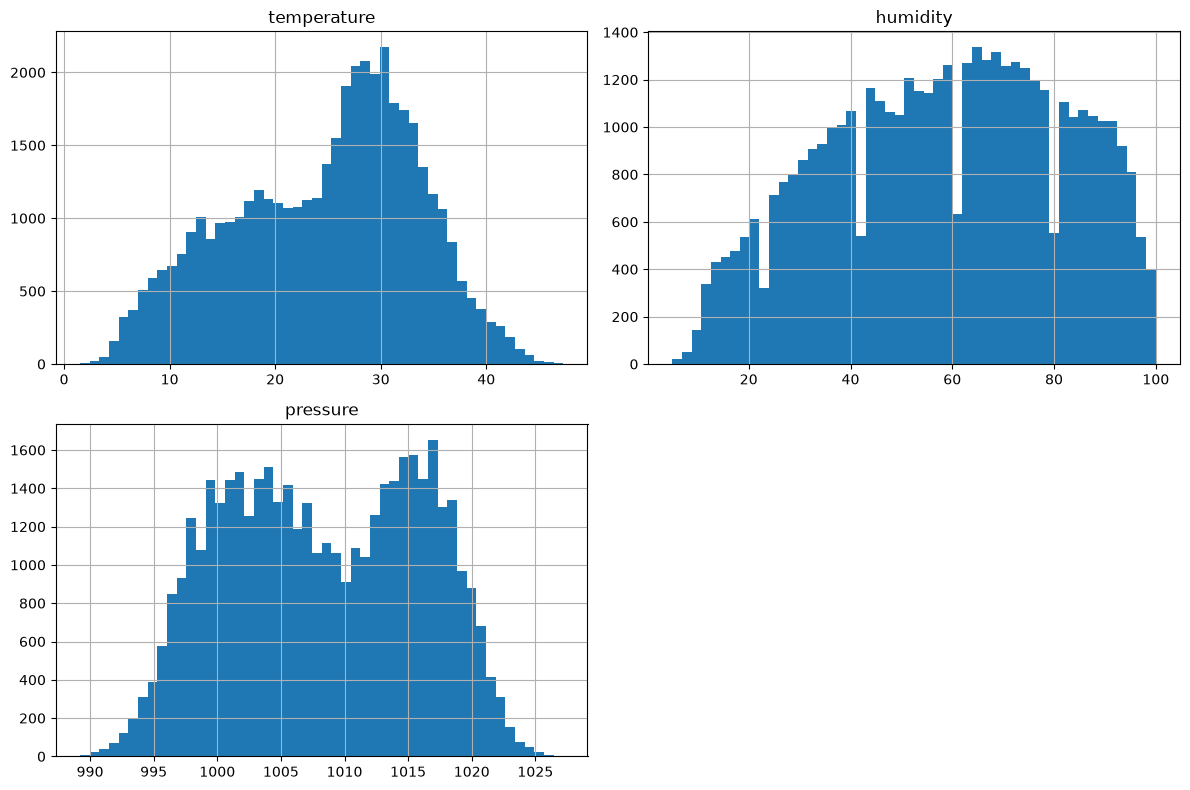

In [98]:
df[["temperature", "humidity", "pressure"]].hist(
    bins=50,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

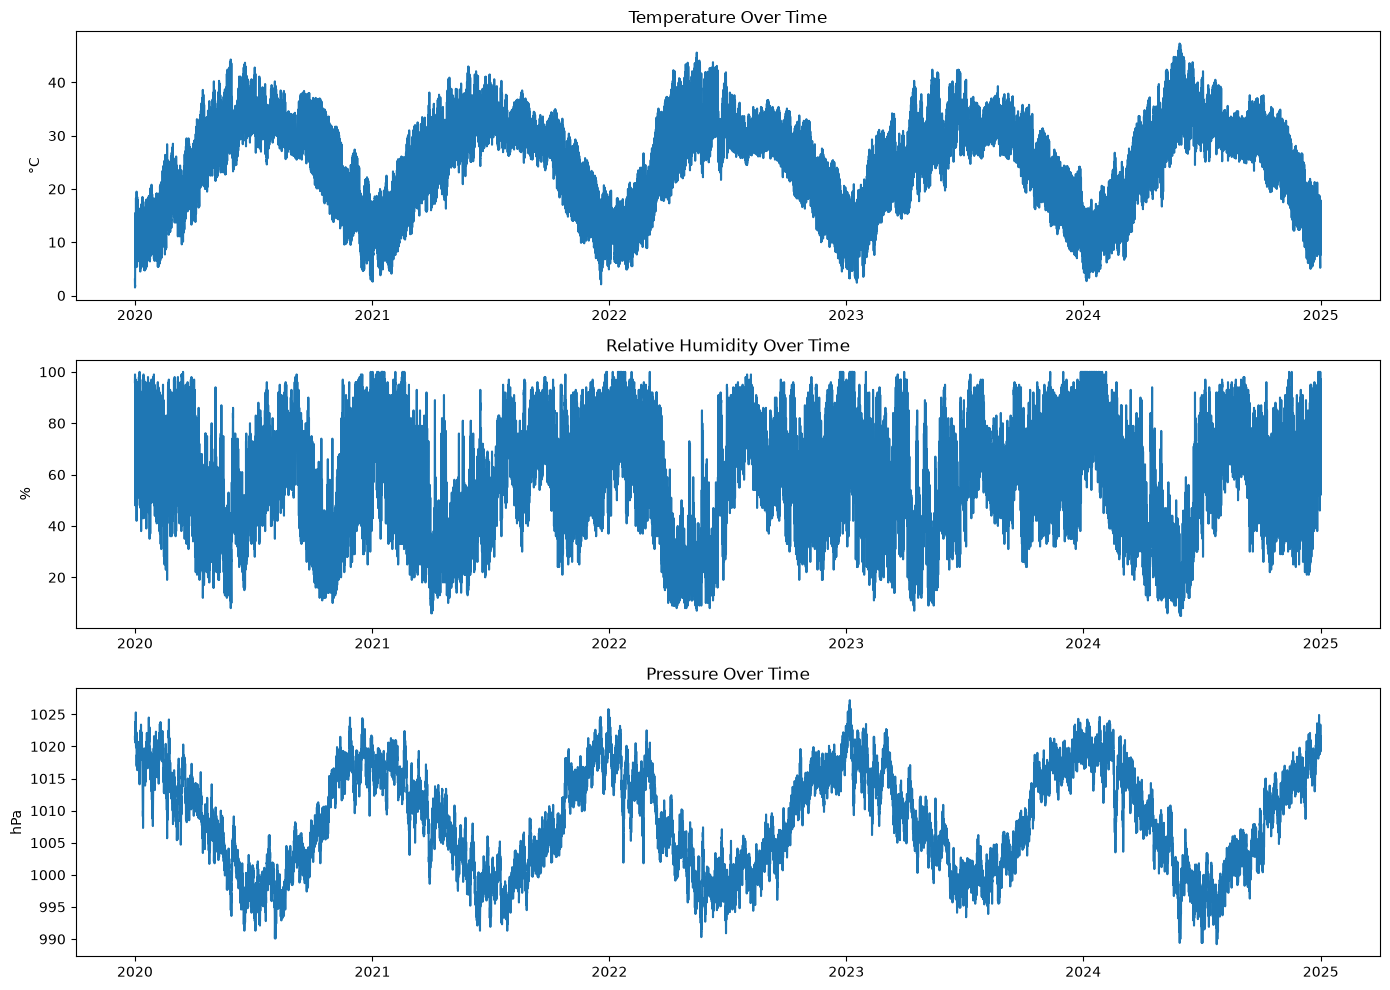

In [99]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df["timestamp"], df["temperature"])
axes[0].set_title("Temperature Over Time")
axes[0].set_ylabel("°C")

axes[1].plot(df["timestamp"], df["humidity"])
axes[1].set_title("Relative Humidity Over Time")
axes[1].set_ylabel("%")

axes[2].plot(df["timestamp"], df["pressure"])
axes[2].set_title("Pressure Over Time")
axes[2].set_ylabel("hPa")

plt.tight_layout()
plt.show()

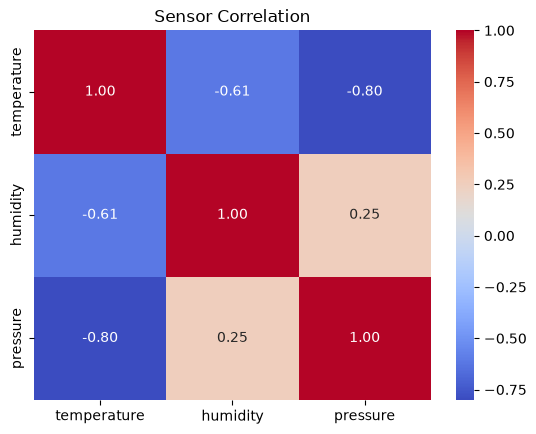

In [100]:
corr = df[["temperature", "humidity", "pressure"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Sensor Correlation")
plt.show()

In [101]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["year"] = df["timestamp"].dt.year

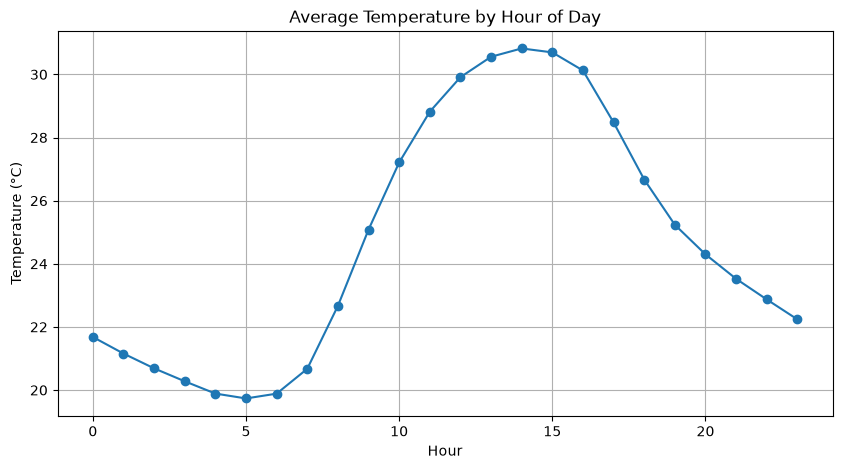

In [102]:
hourly_temp = df.groupby("hour")["temperature"].mean()

hourly_temp.plot(figsize=(10, 5), marker="o")

plt.title("Average Temperature by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

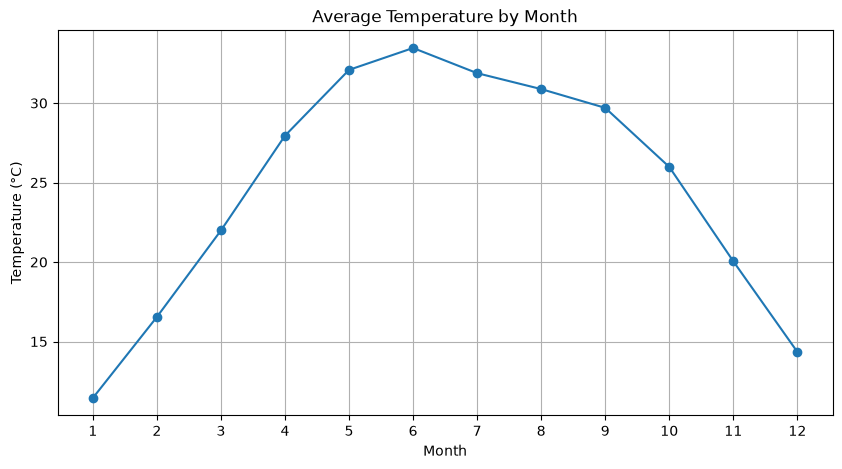

In [103]:
monthly_temp = df.groupby("month")["temperature"].mean()

monthly_temp.plot(figsize=(10, 5), marker="o")

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

In [104]:
df[["temperature", "humidity", "pressure"]].corr()

,temperature,humidity,pressure
temperature,1.000000,-0.611447,-0.800485
humidity,-0.611447,1.000000,0.254298
pressure,-0.800485,0.254298,1.000000


In [105]:
df = df.sort_values("timestamp").reset_index(drop=True)

In [106]:
df["temperature_change"] = df["temperature"].diff()
df["humidity_change"] = df["humidity"].diff()
df["pressure_change"] = df["pressure"].diff()

In [107]:
df["temperature_rolling_mean"] = (
    df["temperature"].rolling(24).mean()
)

df["temperature_rolling_std"] = (
    df["temperature"].rolling(24).std()
)

In [108]:
df["humidity_rolling_mean"] = (
    df["humidity"].rolling(24).mean()
)

df["humidity_rolling_std"] = (
    df["humidity"].rolling(24).std()
)

df["pressure_rolling_mean"] = (
    df["pressure"].rolling(24).mean()
)

df["pressure_rolling_std"] = (
    df["pressure"].rolling(24).std()
)

In [109]:
df["temperature_deviation"] = (
    df["temperature"] - df["temperature_rolling_mean"]
)

df["humidity_deviation"] = (
    df["humidity"] - df["humidity_rolling_mean"]
)

df["pressure_deviation"] = (
    df["pressure"] - df["pressure_rolling_mean"]
)

In [110]:
df.head(30)

,timestamp,temperature,humidity,pressure,hour,day,month,year,temperature_change,humidity_change,pressure_change,temperature_rolling_mean,temperature_rolling_std,humidity_rolling_mean,humidity_rolling_std,pressure_rolling_mean,pressure_rolling_std,temperature_deviation,humidity_deviation,pressure_deviation
0,2020-01-01 00:00:00,3.0,96,1021.5,0,1,1,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 01:00:00,2.5,97,1021.0,1,1,1,2020,-0.5,1.0,-0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 02:00:00,1.9,98,1021.0,2,1,1,2020,-0.6,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 03:00:00,1.7,98,1021.1,3,1,1,2020,-0.2,0.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 04:00:00,1.5,99,1021.1,4,1,1,2020,-0.2,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2020-01-01 05:00:00,2.0,98,1021.4,5,1,1,2020,0.5,-1.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2020-01-01 06:00:00,1.9,98,1021.7,6,1,1,2020,-0.1,0.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2020-01-01 07:00:00,1.7,98,1022.2,7,1,1,2020,-0.2,0.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2020-01-01 08:00:00,3.6,94,1022.7,8,1,1,2020,1.9,-4.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2020-01-01 09:00:00,6.6,85,1023.3,9,1,1,2020,3.0,-9.0,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
df.isnull().sum()

timestamp                    0
temperature                  0
humidity                     0
pressure                     0
hour                         0
day                          0
month                        0
year                         0
temperature_change           1
humidity_change              1
pressure_change              1
temperature_rolling_mean    23
temperature_rolling_std     23
humidity_rolling_mean       23
humidity_rolling_std        23
pressure_rolling_mean       23
pressure_rolling_std        23
temperature_deviation       23
humidity_deviation          23
pressure_deviation          23
dtype: int64

In [112]:
from scipy.stats import zscore

df["temperature_z"] = zscore(df["temperature"])
df["humidity_z"] = zscore(df["humidity"])
df["pressure_z"] = zscore(df["pressure"])

In [113]:
df["zscore_anomaly"] = (
    (df["temperature_z"].abs() > 3) |
    (df["humidity_z"].abs() > 3) |
    (df["pressure_z"].abs() > 3)
)

In [114]:
df["zscore_anomaly"].value_counts()

zscore_anomaly
False    43848
Name: count, dtype: int64

In [115]:
df[df["zscore_anomaly"]][
    ["timestamp", "temperature", "humidity", "pressure",
     "temperature_z", "humidity_z", "pressure_z"]
].head(20)

,timestamp,temperature,humidity,pressure,temperature_z,humidity_z,pressure_z


In [116]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

In [117]:
temp_lower, temp_upper = iqr_bounds(df["temperature"])
hum_lower, hum_upper = iqr_bounds(df["humidity"])
pressure_lower, pressure_upper = iqr_bounds(df["pressure"])

print("Temperature:", temp_lower, "to", temp_upper)
print("Humidity:", hum_lower, "to", hum_upper)
print("Pressure:", pressure_lower, "to", pressure_upper)

Temperature: -1.9500000000000028 to 51.25
Humidity: -13.0 to 131.0
Pressure: 982.25 to 1034.65


In [118]:
df["iqr_anomaly"] = (
    (df["temperature"] < temp_lower) |
    (df["temperature"] > temp_upper) |
    (df["humidity"] < hum_lower) |
    (df["humidity"] > hum_upper) |
    (df["pressure"] < pressure_lower) |
    (df["pressure"] > pressure_upper)
)

In [119]:
df["iqr_anomaly"].value_counts()

iqr_anomaly
False    43848
Name: count, dtype: int64

In [120]:
print("Z-score anomalies:", df["zscore_anomaly"].sum())
print("IQR anomalies:", df["iqr_anomaly"].sum())

Z-score anomalies: 0
IQR anomalies: 0


In [121]:
pd.crosstab(
    df["zscore_anomaly"],
    df["iqr_anomaly"]
)

iqr_anomaly,False
zscore_anomaly,
False,43848


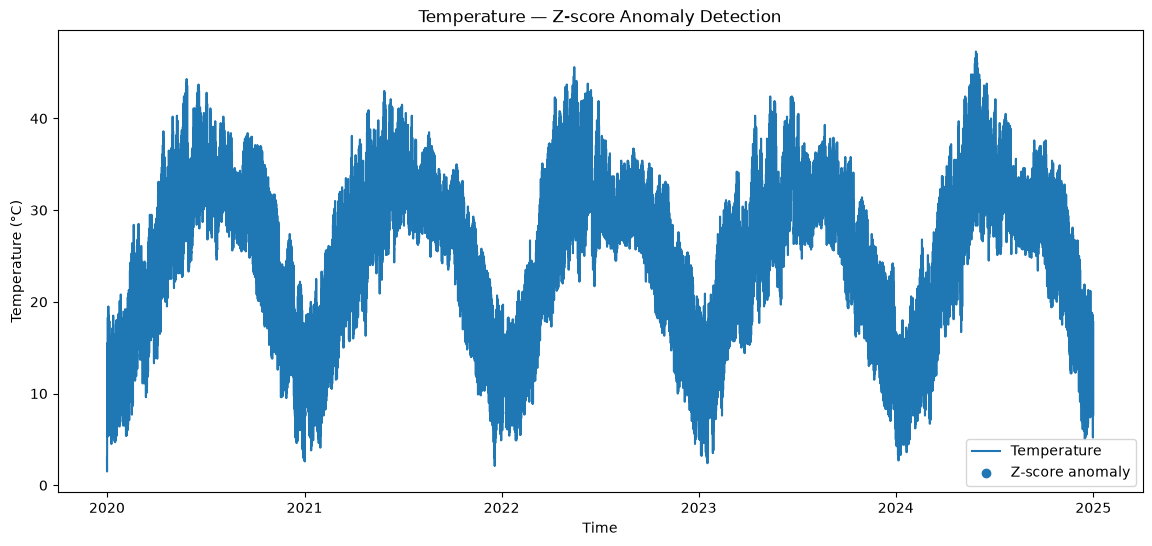

In [122]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["timestamp"],
    df["temperature"],
    label="Temperature"
)

anomalies = df[df["zscore_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature"],
    label="Z-score anomaly"
)

plt.title("Temperature — Z-score Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [123]:
features = [
    "temperature",
    "humidity",
    "pressure",
    "hour",
    "month",
    "temperature_change",
    "humidity_change",
    "pressure_change",
    "temperature_rolling_mean",
    "temperature_rolling_std",
    "humidity_rolling_mean",
    "humidity_rolling_std",
    "pressure_rolling_mean",
    "pressure_rolling_std",
    "temperature_deviation",
    "humidity_deviation",
    "pressure_deviation"
]

In [124]:
ml_df = df.dropna(subset=features).copy()

In [125]:
print("Original rows:", len(df))
print("ML rows:", len(ml_df))

Original rows: 43848
ML rows: 43825


In [126]:
X = ml_df[features]

In [127]:
import sys
print(sys.executable)

from sklearn.ensemble import IsolationForest
print("Isolation Forest is ready!")

c:\Users\Sreoshi\anomaly-detection\.venv\Scripts\python.exe
Isolation Forest is ready!


In [128]:
model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

In [129]:
ml_df["isolation_prediction"] = model.fit_predict(X)

In [130]:
ml_df["isolation_anomaly"] = (
    ml_df["isolation_prediction"] == -1
)

In [131]:
ml_df["isolation_prediction"] = model.fit_predict(X)

ml_df["isolation_anomaly"] = (
    ml_df["isolation_prediction"] == -1
)

In [132]:
print("Isolation Forest anomalies:", ml_df["isolation_anomaly"].sum())

Isolation Forest anomalies: 5522


In [133]:
print(ml_df["isolation_anomaly"].value_counts())

isolation_anomaly
False    38303
True      5522
Name: count, dtype: int64


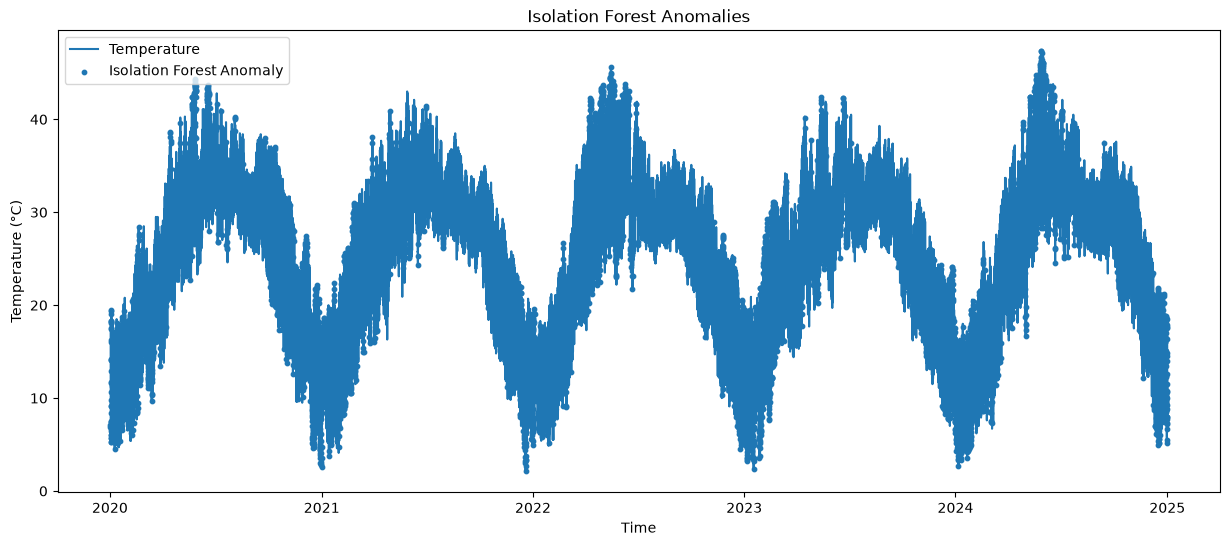

In [134]:
plt.figure(figsize=(15, 6))

plt.plot(
    ml_df["timestamp"],
    ml_df["temperature"],
    label="Temperature"
)

anomalies = ml_df[ml_df["isolation_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature"],
    label="Isolation Forest Anomaly",
    s=10
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Isolation Forest Anomalies")
plt.legend()
plt.show()

In [135]:
ml_df["anomaly_score"] = model.decision_function(X)

In [136]:
ml_df["anomaly_score"].describe()

count    43825.000000
mean         0.036468
std          0.030488
min         -0.118312
25%          0.016968
50%          0.039996
75%          0.059527
max          0.106989
Name: anomaly_score, dtype: float64

In [137]:
ml_df[
    ["timestamp", "temperature", "humidity", "pressure", "anomaly_score"]
].sort_values("anomaly_score").head(10)

,timestamp,temperature,humidity,pressure,anomaly_score
21562,2022-06-17 10:00:00,25.5,84,1002.5,-0.118312
39978,2024-07-23 18:00:00,28.8,87,994.6,-0.107931
39450,2024-07-01 18:00:00,29.9,82,991.9,-0.105307
4108,2020-06-20 04:00:00,28.0,73,1000.3,-0.099829
12413,2021-06-01 05:00:00,25.2,75,1000.7,-0.099340
4637,2020-07-12 05:00:00,27.5,85,996.7,-0.098480
39198,2024-06-21 06:00:00,24.5,92,999.9,-0.094822
18065,2022-01-22 17:00:00,12.9,94,1003.3,-0.094703
38677,2024-05-30 13:00:00,45.7,7,996.3,-0.094315
20967,2022-05-23 15:00:00,26.6,72,995.1,-0.093987


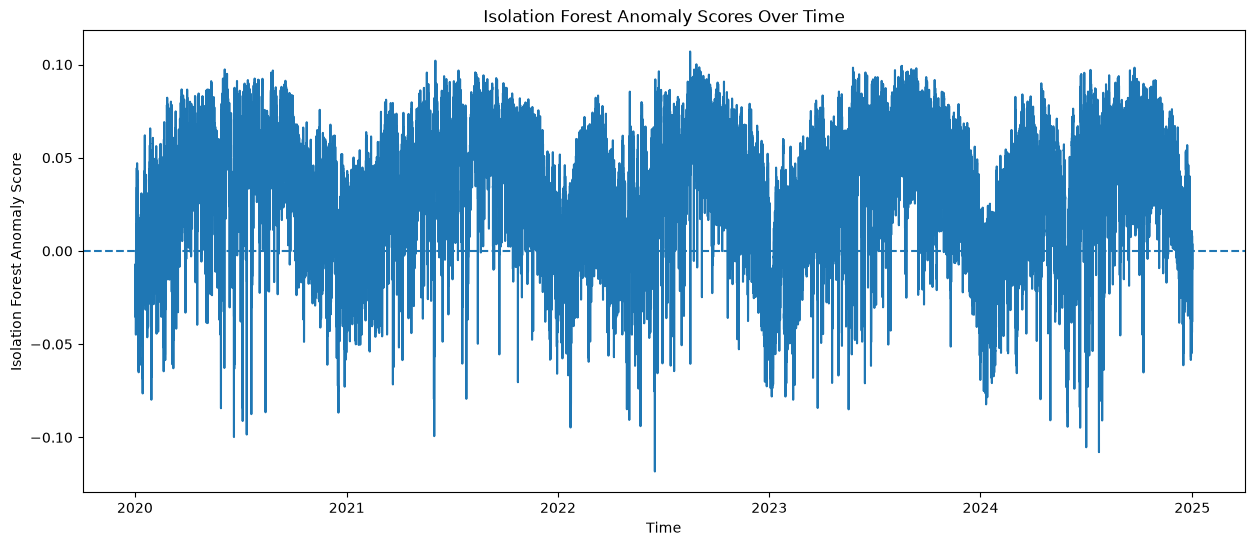

In [138]:
plt.figure(figsize=(15, 6))

plt.plot(
    ml_df["timestamp"],
    ml_df["anomaly_score"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Isolation Forest Anomaly Score")
plt.title("Isolation Forest Anomaly Scores Over Time")
plt.show()

In [139]:
comparison = pd.DataFrame({
    "Z-score": df.loc[ml_df.index, "zscore_anomaly"],
    "IQR": df.loc[ml_df.index, "iqr_anomaly"],
    "Isolation Forest": ml_df["isolation_anomaly"]
})

comparison.sum()

Z-score                0
IQR                    0
Isolation Forest    5522
dtype: int64

In [140]:
from sklearn.preprocessing import StandardScaler

autoencoder_features = [
    "temperature",
    "humidity",
    "pressure",
    "hour",
    "month",
    "temperature_change",
    "humidity_change",
    "pressure_change",
    "temperature_rolling_mean",
    "temperature_rolling_std",
    "humidity_rolling_mean",
    "humidity_rolling_std",
    "pressure_rolling_mean",
    "pressure_rolling_std",
    "temperature_deviation",
    "humidity_deviation",
    "pressure_deviation"
]

ae_df = df.dropna(subset=autoencoder_features).copy()

X_ae = ae_df[autoencoder_features]

print("Autoencoder rows:", len(ae_df))
print("Features:", X_ae.shape[1])

Autoencoder rows: 43825
Features: 17


In [141]:
train_size = int(len(X_ae) * 0.7)
val_size = int(len(X_ae) * 0.15)

X_train = X_ae.iloc[:train_size]
X_val = X_ae.iloc[train_size:train_size + val_size]
X_test = X_ae.iloc[train_size + val_size:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (30677, 17)
Validation: (6573, 17)
Test: (6575, 17)


In [142]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training mean:", X_train_scaled.mean())
print("Training std:", X_train_scaled.std())

Training mean: 5.510937026211347e-16
Training std: 1.0


In [143]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)
test_dataset = TensorDataset(X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print("Train tensor:", X_train_tensor.shape)
print("Validation tensor:", X_val_tensor.shape)

Train tensor: torch.Size([30677, 17])
Validation tensor: torch.Size([6573, 17])


In [144]:
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 12),
            nn.ReLU(),
            nn.Linear(12, 6),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(6, 12),
            nn.ReLU(),
            nn.Linear(12, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


model_ae = Autoencoder(input_dim=X_train_tensor.shape[1])

print(model_ae)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=17, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=6, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=6, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=17, bias=True)
  )
)


In [145]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_ae.parameters(),
    lr=0.001
)

print("Autoencoder ready")

Autoencoder ready


In [146]:
epochs = 30

train_losses = []
val_losses = []

for epoch in range(epochs):

    model_ae.train()
    train_loss = 0.0

    for (batch,) in train_loader:
        optimizer.zero_grad()

        reconstructed = model_ae(batch)
        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model_ae.eval()
    val_loss = 0.0

    with torch.no_grad():
        for (batch,) in val_loader:
            reconstructed = model_ae(batch)
            loss = criterion(reconstructed, batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch [1/30] Train Loss: 0.737096 Val Loss: 0.390272
Epoch [2/30] Train Loss: 0.294880 Val Loss: 0.250587
Epoch [3/30] Train Loss: 0.228377 Val Loss: 0.211786
Epoch [4/30] Train Loss: 0.190277 Val Loss: 0.171327
Epoch [5/30] Train Loss: 0.164354 Val Loss: 0.153986
Epoch [6/30] Train Loss: 0.153913 Val Loss: 0.148699
Epoch [7/30] Train Loss: 0.147923 Val Loss: 0.144010
Epoch [8/30] Train Loss: 0.144807 Val Loss: 0.141916
Epoch [9/30] Train Loss: 0.143120 Val Loss: 0.139916
Epoch [10/30] Train Loss: 0.142351 Val Loss: 0.141024
Epoch [11/30] Train Loss: 0.141593 Val Loss: 0.141024
Epoch [12/30] Train Loss: 0.141110 Val Loss: 0.141258
Epoch [13/30] Train Loss: 0.140695 Val Loss: 0.139397
Epoch [14/30] Train Loss: 0.140365 Val Loss: 0.140479
Epoch [15/30] Train Loss: 0.140040 Val Loss: 0.140130
Epoch [16/30] Train Loss: 0.140010 Val Loss: 0.140729
Epoch [17/30] Train Loss: 0.139771 Val Loss: 0.140405
Epoch [18/30] Train Loss: 0.139587 Val Loss: 0.139668
Epoch [19/30] Train Loss: 0.139512 Va

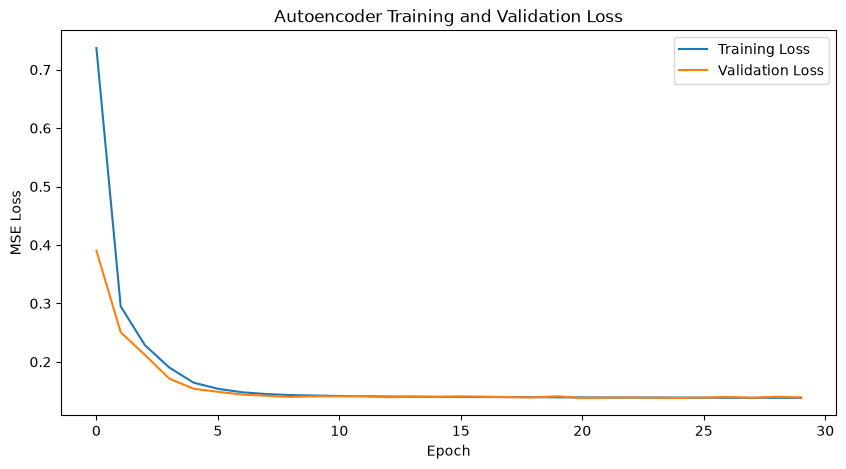

In [147]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.show()

In [148]:
model_ae.eval()

with torch.no_grad():
    X_test_reconstructed = model_ae(X_test_tensor)

reconstruction_error = torch.mean(
    (X_test_tensor - X_test_reconstructed) ** 2,
    dim=1
).numpy()

print("Reconstruction errors:", len(reconstruction_error))
print("Minimum:", reconstruction_error.min())
print("Maximum:", reconstruction_error.max())
print("Mean:", reconstruction_error.mean())

Reconstruction errors: 6575
Minimum: 0.0049844985
Maximum: 1.1540704
Mean: 0.12838738


In [149]:
with torch.no_grad():
    X_val_reconstructed = model_ae(X_val_tensor)

val_reconstruction_error = torch.mean(
    (X_val_tensor - X_val_reconstructed) ** 2,
    dim=1
).numpy()

In [150]:
threshold = np.percentile(val_reconstruction_error, 95)

print("Anomaly threshold:", threshold)

Anomaly threshold: 0.36330807


In [151]:
test_anomaly = reconstruction_error > threshold

print("Autoencoder anomalies:", test_anomaly.sum())
print("Total test observations:", len(test_anomaly))

Autoencoder anomalies: 275
Total test observations: 6575


In [152]:
test_anomaly = reconstruction_error > threshold

print("Autoencoder anomalies:", test_anomaly.sum())
print("Total test observations:", len(test_anomaly))
print("Anomaly percentage:", test_anomaly.mean() * 100)

Autoencoder anomalies: 275
Total test observations: 6575
Anomaly percentage: 4.182509505703422


In [153]:
ae_results = ae_df.iloc[
    train_size + val_size:
].copy()

ae_results["reconstruction_error"] = reconstruction_error
ae_results["autoencoder_anomaly"] = test_anomaly

print(ae_results["autoencoder_anomaly"].value_counts())

autoencoder_anomaly
False    6300
True      275
Name: count, dtype: int64


In [154]:
ae_results[
    [
        "timestamp",
        "temperature",
        "humidity",
        "pressure",
        "reconstruction_error"
    ]
].sort_values(
    "reconstruction_error",
    ascending=False
).head(10)

,timestamp,temperature,humidity,pressure,reconstruction_error
41824,2024-10-08 16:00:00,22.7,88,1013.4,1.154070
39182,2024-06-20 14:00:00,28.8,72,996.8,1.151912
39183,2024-06-20 15:00:00,35.5,49,994.3,1.126394
37554,2024-04-13 18:00:00,22.9,70,1011.1,1.050305
39503,2024-07-03 23:00:00,31.5,75,996.5,0.858560
41826,2024-10-08 18:00:00,27.0,64,1011.3,0.851490
39474,2024-07-02 18:00:00,37.6,46,990.5,0.850800
39513,2024-07-04 09:00:00,28.8,83,1000.0,0.838816
37555,2024-04-13 19:00:00,21.7,84,1011.0,0.826759
43655,2024-12-23 23:00:00,10.4,93,1018.1,0.822807


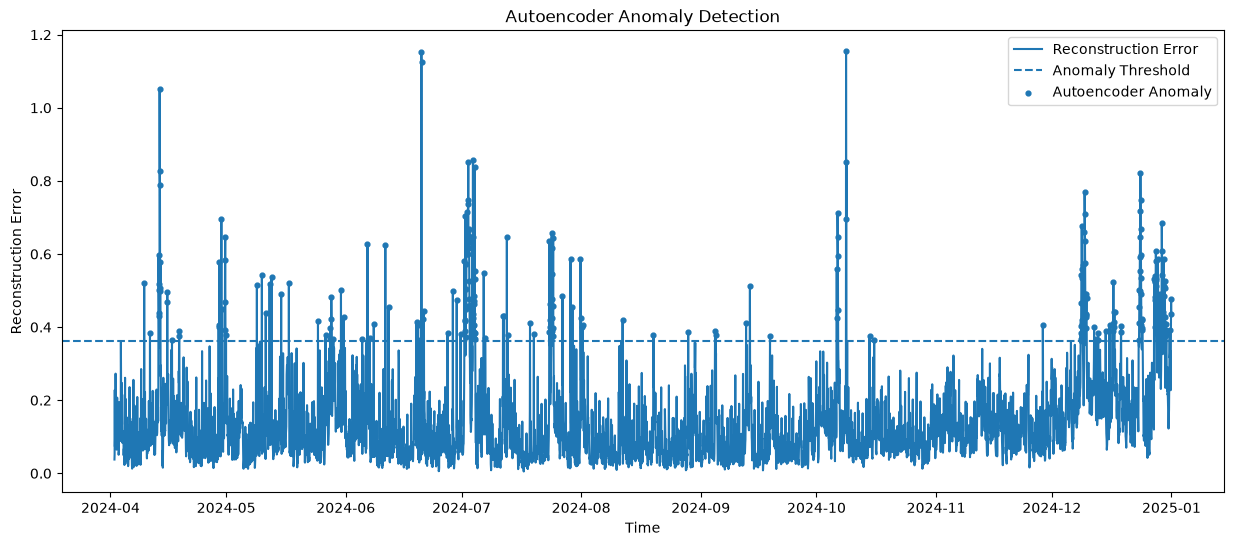

In [155]:
plt.figure(figsize=(15, 6))

plt.plot(
    ae_results["timestamp"],
    ae_results["reconstruction_error"],
    label="Reconstruction Error"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Anomaly Threshold"
)

anomalies = ae_results[ae_results["autoencoder_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["reconstruction_error"],
    label="Autoencoder Anomaly",
    s=12
)

plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.title("Autoencoder Anomaly Detection")
plt.legend()
plt.show()

In [156]:
print("Autoencoder anomalies:", ae_results["autoencoder_anomaly"].sum())
print(
    "Anomaly percentage:",
    ae_results["autoencoder_anomaly"].mean() * 100
)

Autoencoder anomalies: 275
Anomaly percentage: 4.182509505703422


In [157]:
# Z-score baseline
from scipy.stats import zscore

sensor_cols = ["temperature", "humidity", "pressure"]

z_scores = ml_df[sensor_cols].apply(zscore)

ml_df["zscore_anomaly"] = (z_scores.abs() > 3).any(axis=1)


# IQR baseline
iqr_anomaly = pd.Series(False, index=ml_df.index)

for col in sensor_cols:
    Q1 = ml_df[col].quantile(0.25)
    Q3 = ml_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_anomaly |= (
        (ml_df[col] < lower) |
        (ml_df[col] > upper)
    )

ml_df["iqr_anomaly"] = iqr_anomaly

print("Z-score anomalies:", ml_df["zscore_anomaly"].sum())
print("IQR anomalies:", ml_df["iqr_anomaly"].sum())
print("Isolation Forest anomalies:", ml_df["isolation_anomaly"].sum())

Z-score anomalies: 0
IQR anomalies: 0
Isolation Forest anomalies: 5522


In [160]:
comparison = ml_df[
    [
        "timestamp",
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_anomaly"
    ]
].copy()

comparison = comparison.merge(
    ae_results[
        [
            "timestamp",
            "reconstruction_error",
            "autoencoder_anomaly"
        ]
    ],
    on="timestamp",
    how="left"
)

print(comparison.columns.tolist())

['timestamp', 'zscore_anomaly', 'iqr_anomaly', 'isolation_anomaly', 'reconstruction_error', 'autoencoder_anomaly']


In [161]:
print(
    comparison[
        [
            "zscore_anomaly",
            "iqr_anomaly",
            "isolation_anomaly",
            "autoencoder_anomaly"
        ]
    ].sum()
)

zscore_anomaly            0
iqr_anomaly               0
isolation_anomaly      5522
autoencoder_anomaly     275
dtype: object


In [162]:
print(ml_df["zscore_anomaly"].value_counts(dropna=False))
print()
print(ml_df["iqr_anomaly"].value_counts(dropna=False))

zscore_anomaly
False    43825
Name: count, dtype: int64

iqr_anomaly
False    43825
Name: count, dtype: int64


In [163]:
test_comparison = comparison[
    comparison["autoencoder_anomaly"].notna()
].copy()

print("Common comparison observations:", len(test_comparison))

Common comparison observations: 6575


In [164]:
method_counts = test_comparison[
    [
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_anomaly",
        "autoencoder_anomaly"
    ]
].sum()

print(method_counts)

zscore_anomaly           0
iqr_anomaly              0
isolation_anomaly      757
autoencoder_anomaly    275
dtype: object


In [165]:
test_comparison["methods_detecting"] = test_comparison[
    [
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_anomaly",
        "autoencoder_anomaly"
    ]
].sum(axis=1)

print(
    test_comparison["methods_detecting"]
    .value_counts()
    .sort_index()
)

methods_detecting
0    5727
1     664
2     184
Name: count, dtype: int64


In [166]:
ml_overlap = test_comparison[
    (test_comparison["isolation_anomaly"]) &
    (test_comparison["autoencoder_anomaly"])
]

print("Detected by both ML methods:", len(ml_overlap))

Detected by both ML methods: 184


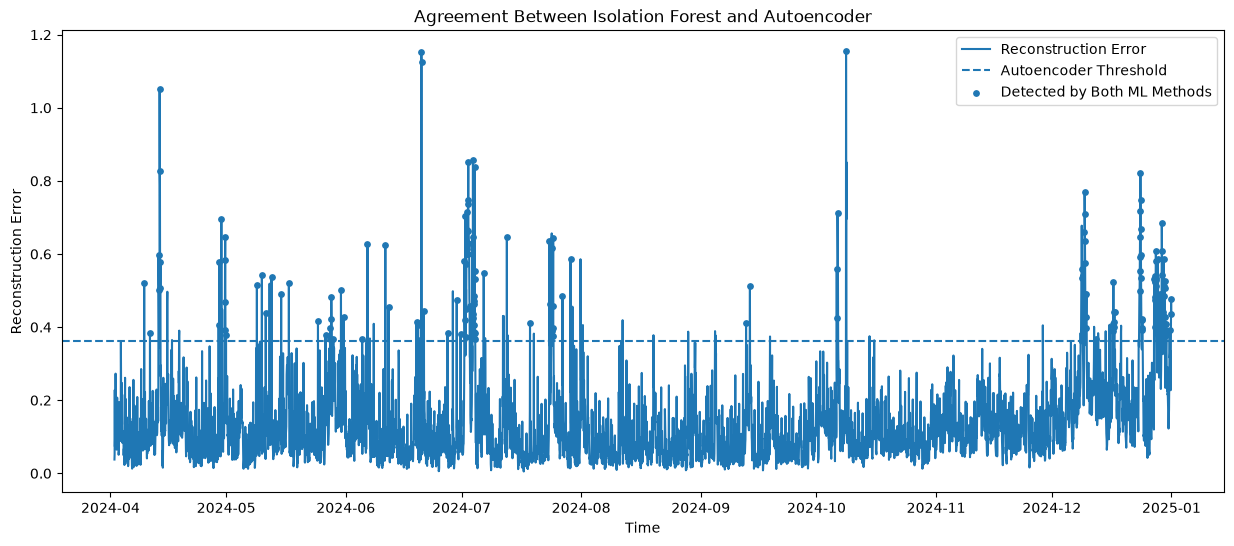

In [167]:
plt.figure(figsize=(15, 6))

plt.plot(
    test_comparison["timestamp"],
    test_comparison["reconstruction_error"],
    label="Reconstruction Error"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Autoencoder Threshold"
)

plt.scatter(
    ml_overlap["timestamp"],
    ml_overlap["reconstruction_error"],
    s=15,
    label="Detected by Both ML Methods"
)

plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.title("Agreement Between Isolation Forest and Autoencoder")
plt.legend()
plt.show()